In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load Data**

In [12]:
df = pd.read_csv('../data/heart_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [13]:
df.duplicated().sum()

np.int64(18078)

In [14]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [15]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301717 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      301717 non-null  object 
 1   BMI               301717 non-null  float64
 2   Smoking           301717 non-null  object 
 3   AlcoholDrinking   301717 non-null  object 
 4   Stroke            301717 non-null  object 
 5   PhysicalHealth    301717 non-null  float64
 6   MentalHealth      301717 non-null  float64
 7   DiffWalking       301717 non-null  object 
 8   Sex               301717 non-null  object 
 9   AgeCategory       301717 non-null  object 
 10  Race              301717 non-null  object 
 11  Diabetic          301717 non-null  object 
 12  PhysicalActivity  301717 non-null  object 
 13  GenHealth         301717 non-null  object 
 14  SleepTime         301717 non-null  float64
 15  Asthma            301717 non-null  object 
 16  KidneyDisease     301717 

In [16]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


## **Preprocessing**

In [17]:
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 60)]

In [18]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [19]:
df['HeartDisease'].value_counts()

HeartDisease
No     274021
Yes     27204
Name: count, dtype: int64

In [20]:
df['HeartDisease'] = (df['HeartDisease'] == 'Yes').astype(int)
df['HeartDisease'].value_counts()

HeartDisease
0    274021
1     27204
Name: count, dtype: int64

In [21]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [22]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,0,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,0,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,0,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,0,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [23]:
cols = ['Smoking', 'AlcoholDrinking', 'Stroke','DiffWalking','Diabetic', 'PhysicalActivity','Asthma', 'KidneyDisease', 'SkinCancer']
for col in cols:
    df[col] = (df[col] == 'Yes').astype(int)
    print(f"{col} value counts:\n{df[col].value_counts()}\n")

Smoking value counts:
Smoking
0    174021
1    127204
Name: count, dtype: int64

AlcoholDrinking value counts:
AlcoholDrinking
0    279675
1     21550
Name: count, dtype: int64

Stroke value counts:
Stroke
0    289188
1     12037
Name: count, dtype: int64

DiffWalking value counts:
DiffWalking
0    257134
1     44091
Name: count, dtype: int64

Diabetic value counts:
Diabetic
0    260792
1     40433
Name: count, dtype: int64

PhysicalActivity value counts:
PhysicalActivity
1    230163
0     71062
Name: count, dtype: int64

Asthma value counts:
Asthma
0    258727
1     42498
Name: count, dtype: int64

KidneyDisease value counts:
KidneyDisease
0    289492
1     11733
Name: count, dtype: int64

SkinCancer value counts:
SkinCancer
0    271950
1     29275
Name: count, dtype: int64



In [24]:
df['Sex'] = (df['Sex'] == 'Male').astype(int)
df['Sex'].value_counts()

Sex
0    159353
1    141872
Name: count, dtype: int64

In [25]:
df = df.drop(columns = ['Race'], axis = 1)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,55-59,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,80 or older,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,65-69,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,75-79,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,40-44,0,1,Very good,8.0,0,0,0


In [26]:
df['AgeCategory'].unique()

array(['55-59', '80 or older', '65-69', '75-79', '40-44', '70-74',
       '60-64', '50-54', '45-49', '18-24', '35-39', '30-34', '25-29'],
      dtype=object)

In [27]:
df['AgeCategory'] = df['AgeCategory'].map({
    '18-24': 0,'25-29': 1,'30-34': 2,'35-39': 3,'40-44': 4,'45-49': 5,'50-54': 6,
    '55-59': 7,'60-64': 8,'65-69': 9,'70-74': 10,'75-79': 11,'80 or older': 12})

df['AgeCategory'].value_counts()

AgeCategory
9     31642
8     31177
10    29259
7     27547
6     23673
12    23344
11    20710
5     20456
0     19973
4     19777
3     19473
2     17904
1     16290
Name: count, dtype: int64

In [28]:
df['GenHealth'].unique()

array(['Very good', 'Fair', 'Good', 'Poor', 'Excellent'], dtype=object)

In [29]:
df['GenHealth'] = df['GenHealth'].map({
    'Poor': 0,'Fair': 1,'Good': 2,'Very good': 3,'Excellent': 4})

df['GenHealth'].value_counts()

GenHealth
3    104740
2     91090
4     59701
1     34503
0     11191
Name: count, dtype: int64

In [30]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,1,1,3,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,1,3,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,1,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,0,1,3,8.0,0,0,0


In [31]:
df.duplicated().sum()

np.int64(7119)

In [32]:
df = df.drop_duplicates()

## **Data Visualization**

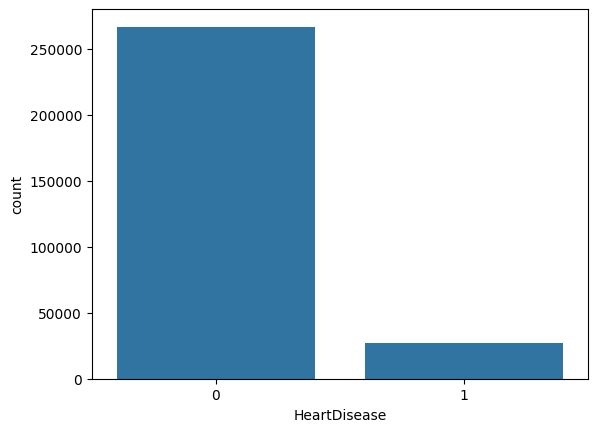

In [33]:
sns.countplot(x = 'HeartDisease', data = df)
plt.show()

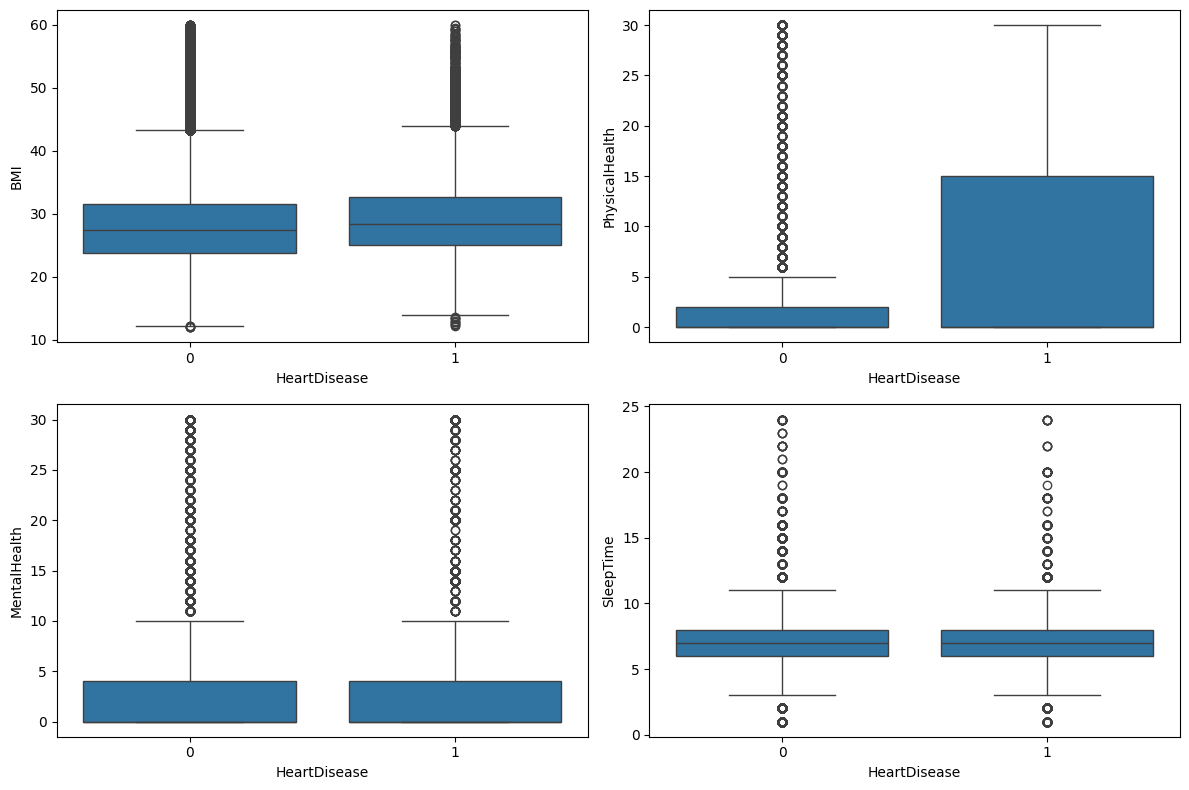

In [34]:
nums_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

fig, axes = plt.subplots(2,2,figsize = (12,8))
axes = axes.flatten()

for i,col in enumerate(nums_cols):
    sns.boxplot(x='HeartDisease', y=col, data=df, ax=axes[i])
plt.tight_layout()
plt.show()

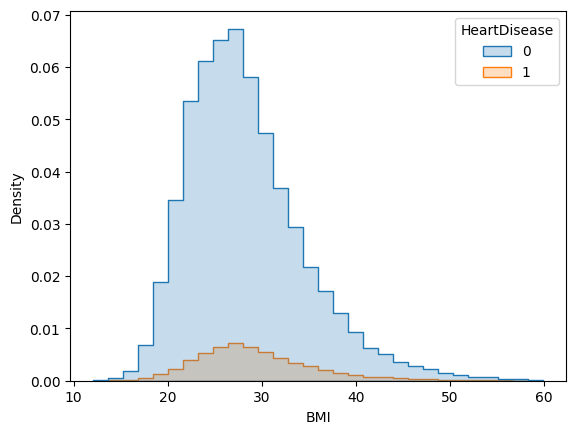

In [35]:
sns.histplot(data=df, x = 'BMI', hue = 'HeartDisease', bins=30, element='step', stat='density')
plt.show()

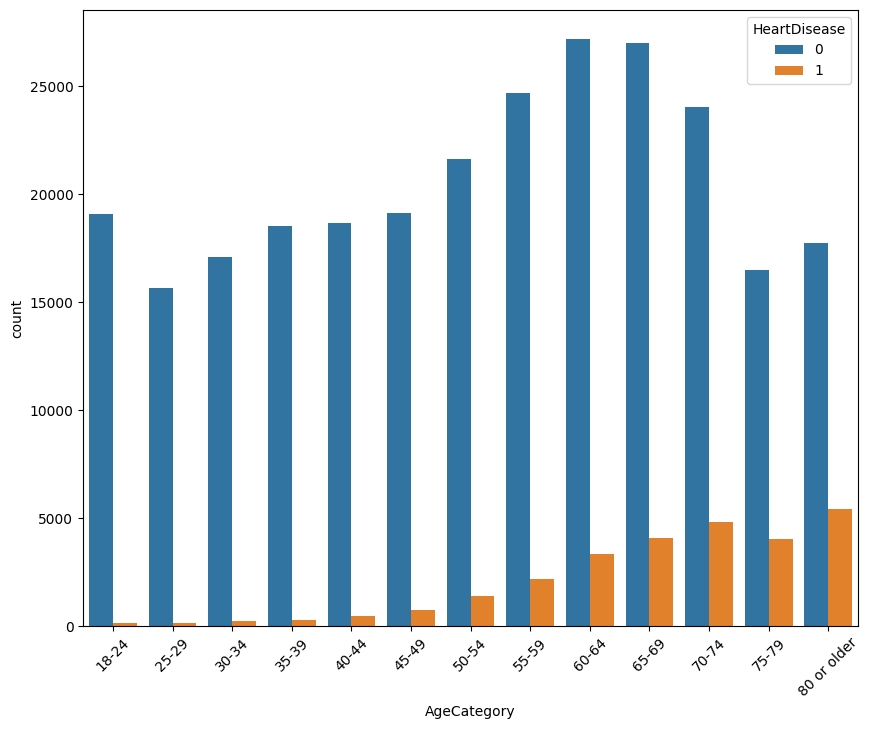

In [36]:
plt.figure(figsize = (10,8))
sns.countplot(data=df, x = 'AgeCategory', hue = 'HeartDisease')
plt.xticks(rotation = 45,ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12],
labels=['18-24','25-29','30-34','35-39','40-44','45-49',
'50-54','55-59', '60-64','65-69','70-74', '75-79', '80 or older'])
plt.show()

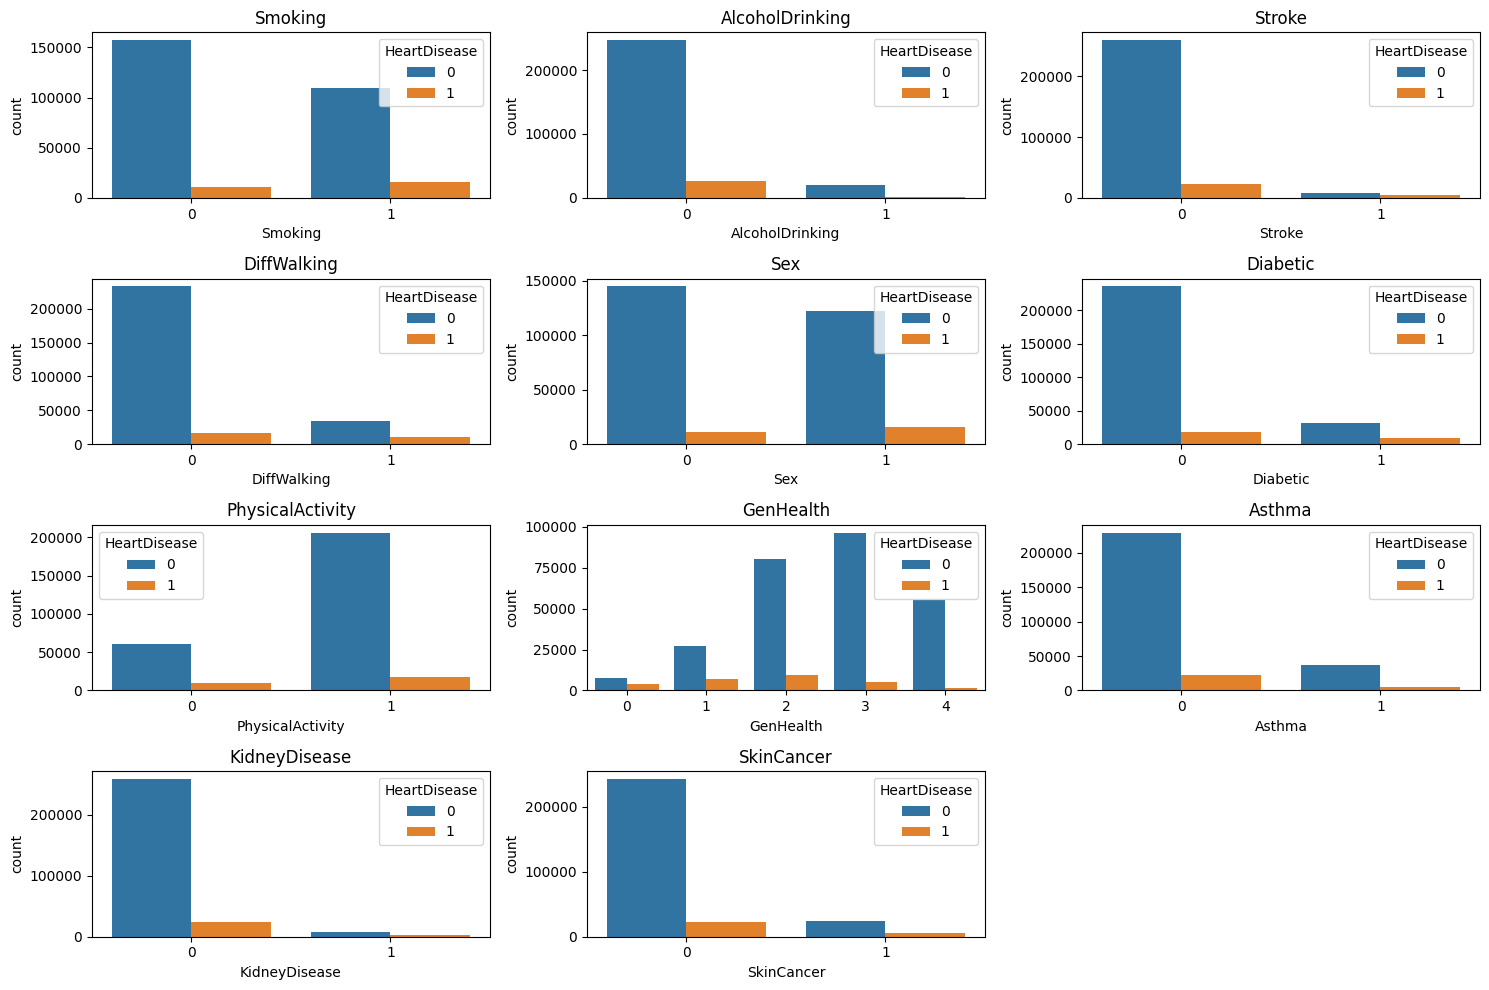

In [37]:
cat_cols = ['Smoking','AlcoholDrinking','Stroke','DiffWalking',
            'Sex','Diabetic','PhysicalActivity','GenHealth',
            'Asthma','KidneyDisease','SkinCancer']

n_cols = 3
n_rows = 4 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x')


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

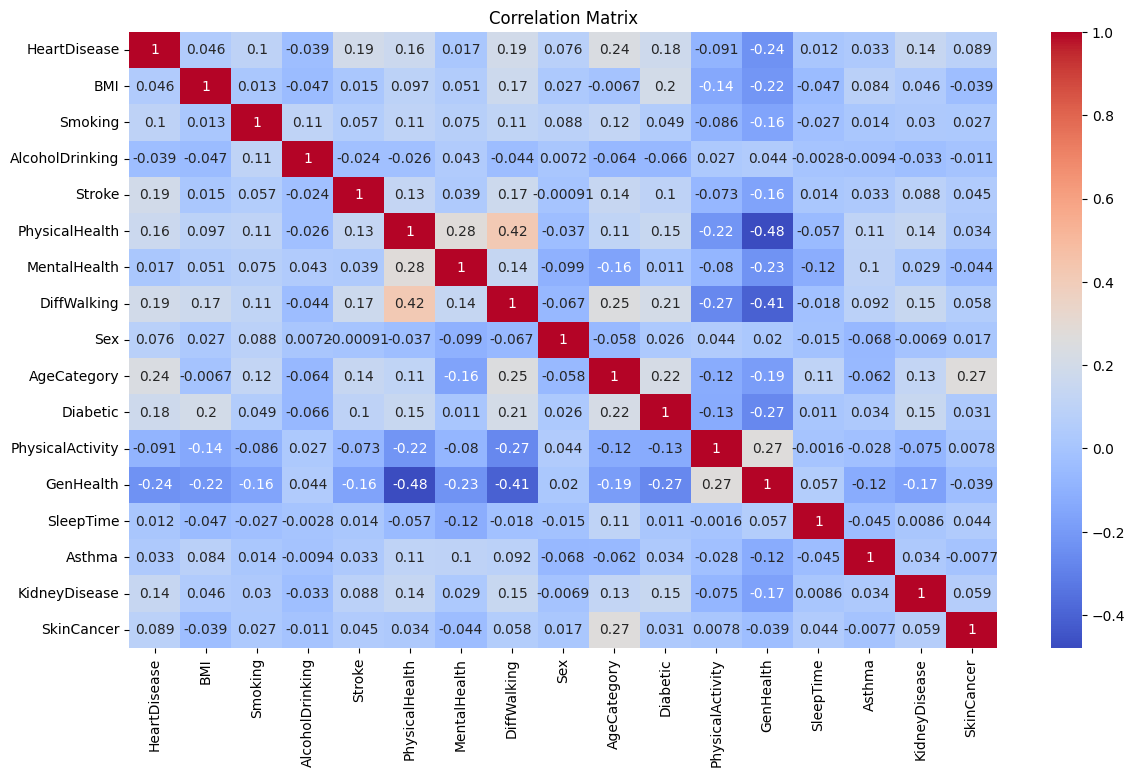

In [38]:
plt.figure(figsize=(14,8))
sns.heatmap(data = df.corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## **Train Models**

In [39]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['HeartDisease'], axis = 1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\MUHAMMED\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     53385
           1       0.53      0.11      0.18      5437

    accuracy                           0.91     58822
   macro avg       0.72      0.55      0.57     58822
weighted avg       0.88      0.91      0.88     58822



In [42]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=300, max_depth=15)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.81      0.87     53385
           1       0.25      0.63      0.36      5437

    accuracy                           0.79     58822
   macro avg       0.60      0.72      0.61     58822
weighted avg       0.89      0.79      0.83     58822



In [44]:
importance = model_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp[:12])

           Feature  Importance
8      AgeCategory    0.315268
11       GenHealth    0.147634
0              BMI    0.101175
6      DiffWalking    0.055724
4   PhysicalHealth    0.055523
9         Diabetic    0.052654
3           Stroke    0.049980
12       SleepTime    0.047928
7              Sex    0.044299
5     MentalHealth    0.041062
1          Smoking    0.023122
14   KidneyDisease    0.017774


##### **Solve The Imbalance**

In [45]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss

rus = RandomUnderSampler(random_state=42)
X_balanced  ,y_balanced= rus.fit_resample(X, y)
y_balanced.value_counts()

HeartDisease
0    27184
1    27184
Name: count, dtype: int64

#### **Models Comparison**

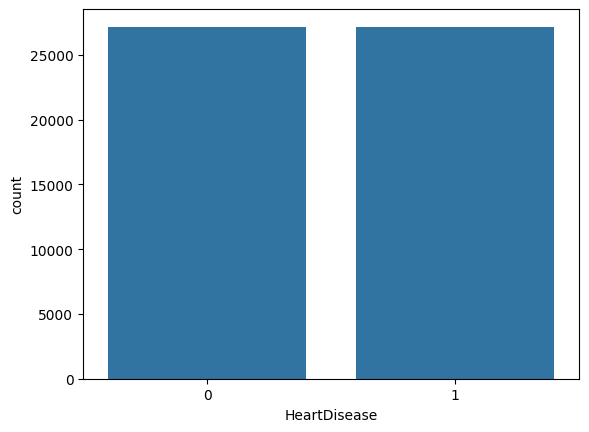

In [46]:
sns.countplot(x = 'HeartDisease', data = pd.DataFrame(y_balanced))
plt.show()

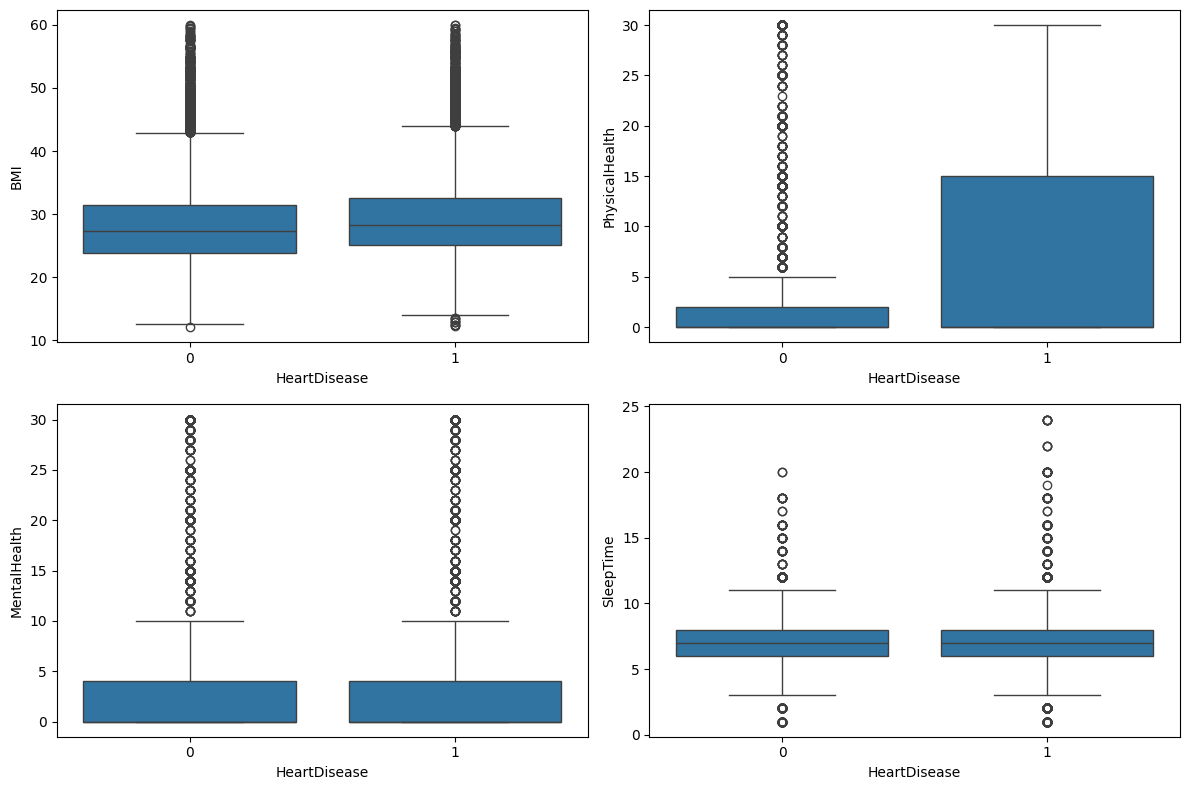

In [47]:
nums_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

fig, axes = plt.subplots(2,2,figsize = (12,8))
axes = axes.flatten()
data = X_balanced.copy()
data['HeartDisease'] = y_balanced
for i,col in enumerate(nums_cols):
    sns.boxplot(x='HeartDisease', y=col, data=data, ax=axes[i])
plt.tight_layout()
plt.show()

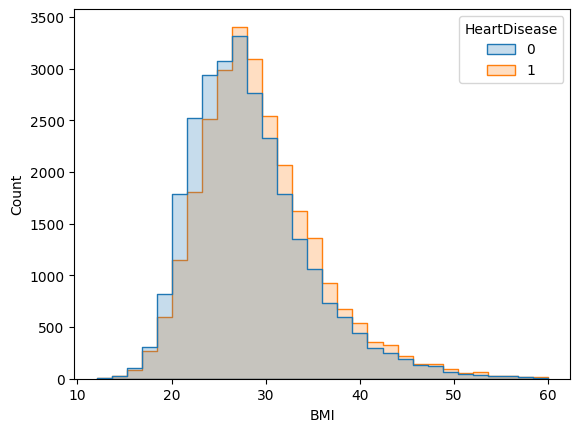

In [48]:
sns.histplot(data=data, x = 'BMI', hue = 'HeartDisease', bins=30, element='step')
plt.show()

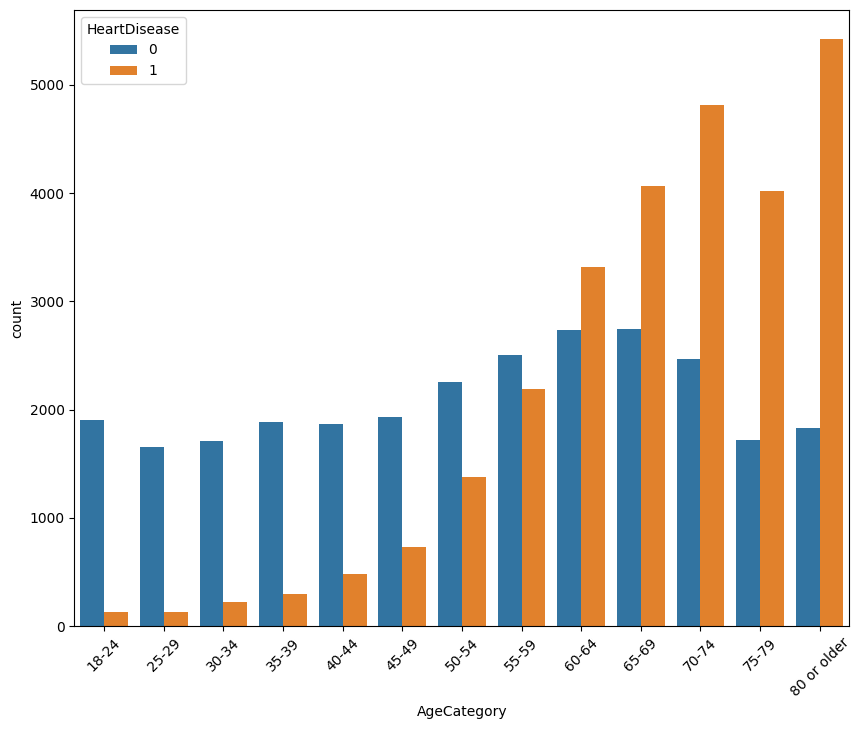

In [49]:
plt.figure(figsize = (10,8))
sns.countplot(data=data, x = 'AgeCategory', hue = 'HeartDisease')
plt.xticks(rotation = 45,ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12],
labels=['18-24','25-29','30-34','35-39','40-44','45-49',
'50-54','55-59', '60-64','65-69','70-74', '75-79', '80 or older'])
plt.show()

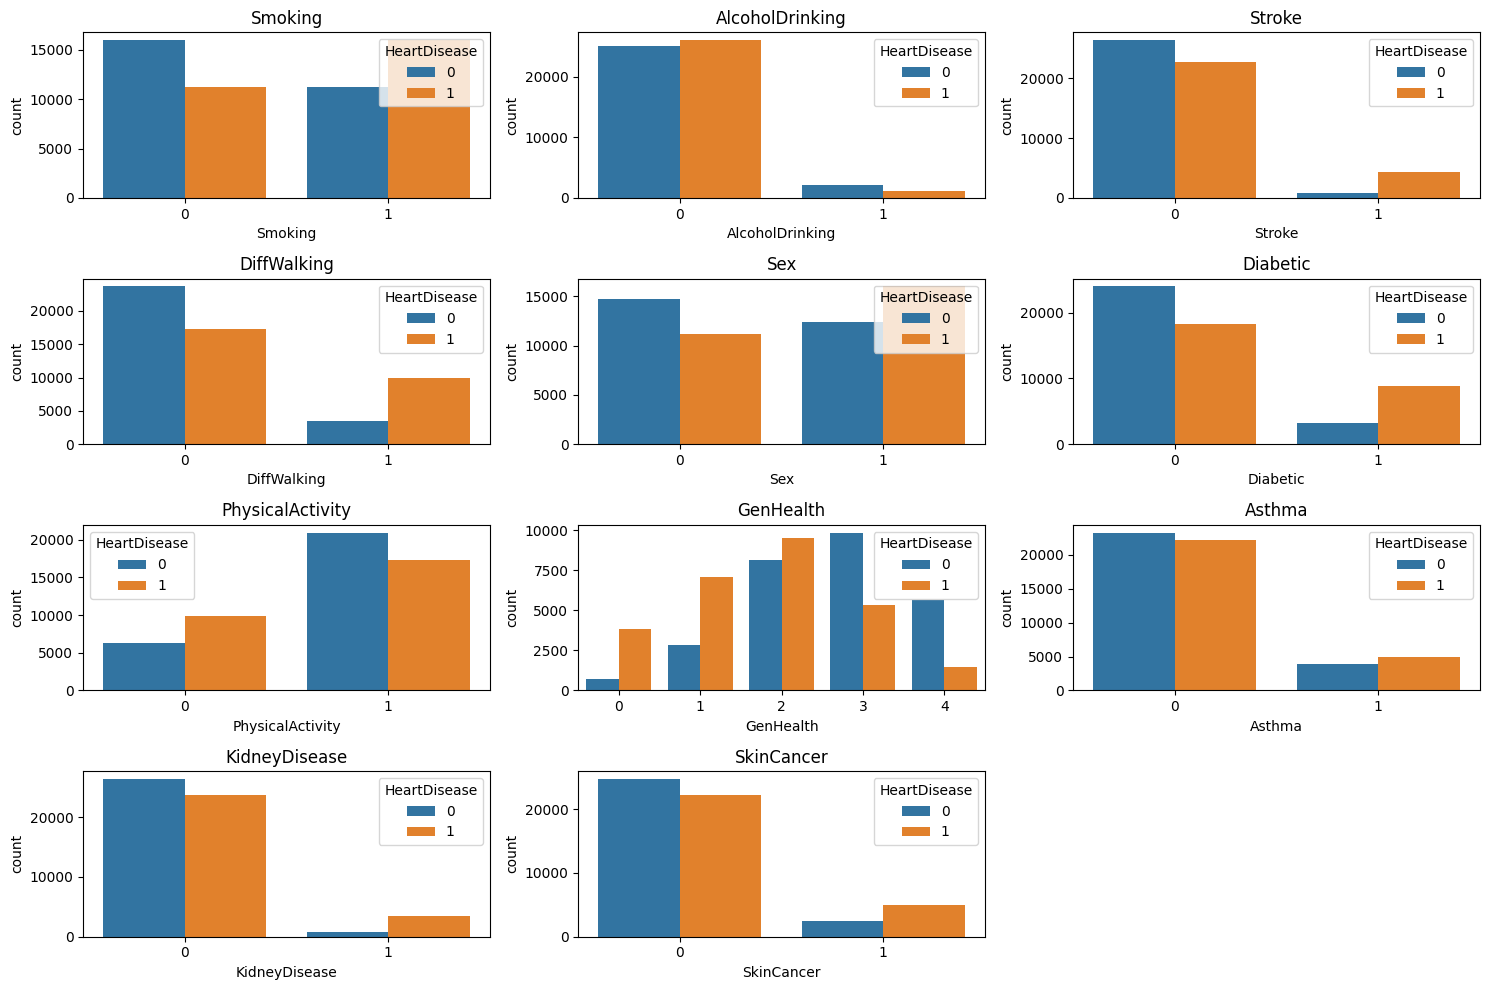

In [50]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=data, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

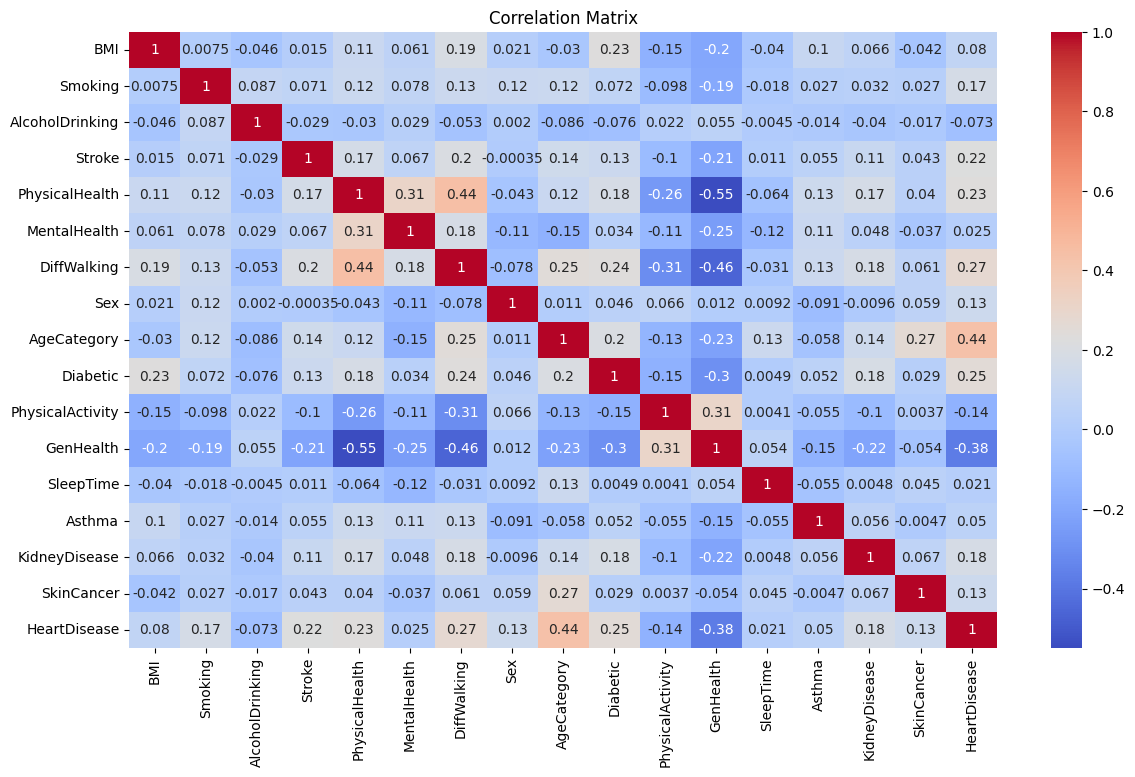

In [51]:
plt.figure(figsize=(14,8))
sns.heatmap(data = data.corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

In [53]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=10)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.73      5437
           1       0.72      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



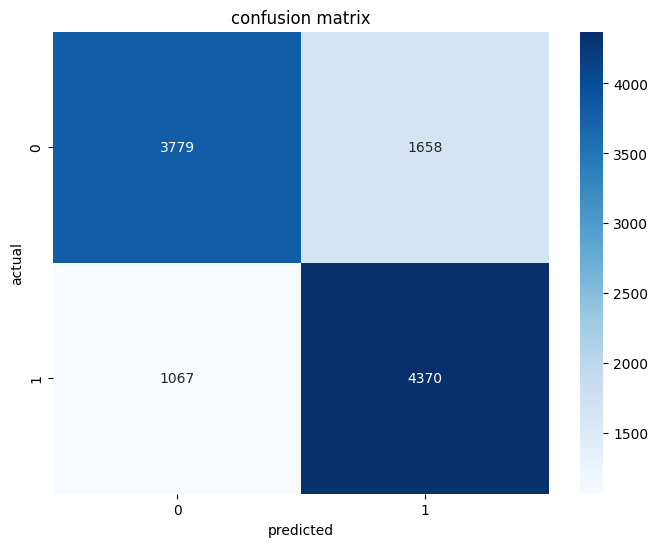

In [55]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (8,6))
sns.heatmap(data = cm, cmap='Blues', annot=True, fmt='d', xticklabels=['0','1'],
yticklabels = ['0','1'])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

In [56]:
importance = model_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp[:12])

           Feature  Importance
8      AgeCategory    0.375331
11       GenHealth    0.187283
9         Diabetic    0.071778
6      DiffWalking    0.070018
3           Stroke    0.059788
7              Sex    0.046233
4   PhysicalHealth    0.045095
0              BMI    0.038595
1          Smoking    0.021934
12       SleepTime    0.019444
14   KidneyDisease    0.018896
5     MentalHealth    0.018807


In [57]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = model_rf.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.823873753935468


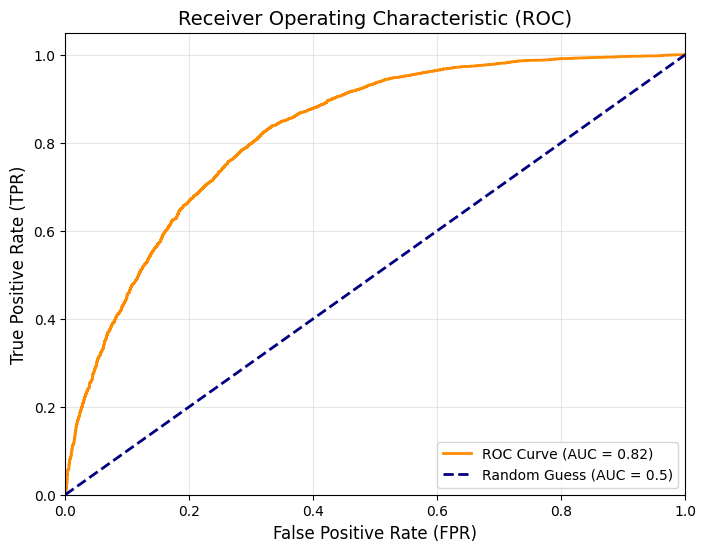

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color = 'darkorange', lw=2, label = f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2, label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [59]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(random_state=42, n_estimators=100, max_depth=5, objective='binary:logistic')
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.70      0.74      5437
           1       0.73      0.79      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



In [60]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.73      0.74      5437
           1       0.74      0.77      0.75      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



In [61]:
from sklearn.tree import DecisionTreeClassifier
model_tr = DecisionTreeClassifier()
model_tr.fit(X_train, y_train)
y_pred = model_tr.predict(X_test)

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      5437
           1       0.65      0.66      0.65      5437

    accuracy                           0.65     10874
   macro avg       0.65      0.65      0.65     10874
weighted avg       0.65      0.65      0.65     10874



In [63]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
y_pred = model_NB.predict(X_test)

In [64]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.80      0.72      5437
           1       0.74      0.58      0.65      5437

    accuracy                           0.69     10874
   macro avg       0.70      0.69      0.69     10874
weighted avg       0.70      0.69      0.69     10874



In [65]:
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(n_estimators = 200, 
max_depth = 3,
random_state = 42,
learning_rate = 0.1)

model_gb.fit(X_train, y_train)
y_pred = model_gb.predict(X_test)

In [66]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      5437
           1       0.73      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



***Feature Engineering***

In [67]:
risk_columns = ['Smoking', 'Stroke', 'DiffWalking', 'Diabetic', 'Asthma', 'KidneyDisease', 'SkinCancer']
df['Risk_Score'] = df[risk_columns].sum(axis=1)

In [68]:
df['PoorHealthDays'] = df['PhysicalHealth'] + df['MentalHealth']

In [69]:
df['AbnormalSleep'] = df['SleepTime'].apply(lambda x: 1 if x < 7 or x > 9 else 0)

In [70]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif 18.5 <= bmi < 25:
        return 1  # Normal
    elif 25 <= bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese


df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

In [71]:
df[['Risk_Score', 'PoorHealthDays', 'AbnormalSleep', 'BMI_Category']].head()

,Risk_Score,PoorHealthDays,AbnormalSleep,BMI_Category
0,4,33.0,1,0
1,1,0.0,0,1
2,3,50.0,0,2
3,1,0.0,1,1
4,1,28.0,0,1


In [72]:
df_feature = df[['Risk_Score', 'PoorHealthDays', 'AbnormalSleep', 'BMI_Category','Sex', 'AgeCategory','AlcoholDrinking','PhysicalActivity', 'GenHealth','HeartDisease']]

In [73]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma',
       'KidneyDisease', 'SkinCancer', 'Risk_Score', 'PoorHealthDays',
       'AbnormalSleep', 'BMI_Category'],
      dtype='object')

In [74]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294106 entries, 0 to 319794
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Risk_Score        294106 non-null  int64  
 1   PoorHealthDays    294106 non-null  float64
 2   AbnormalSleep     294106 non-null  int64  
 3   BMI_Category      294106 non-null  int64  
 4   Sex               294106 non-null  int64  
 5   AgeCategory       294106 non-null  int64  
 6   AlcoholDrinking   294106 non-null  int64  
 7   PhysicalActivity  294106 non-null  int64  
 8   GenHealth         294106 non-null  int64  
 9   HeartDisease      294106 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 24.7 MB


In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scalling_col = ['PoorHealthDays']
df_feature[scalling_col] = scaler.fit_transform(df_feature[scalling_col])
df_feature.head()

C:\Users\MUHAMMED\AppData\Local\Temp\ipykernel_7924\3936836314.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature[scalling_col] = scaler.fit_transform(df_feature[scalling_col])


,Risk_Score,PoorHealthDays,AbnormalSleep,BMI_Category,Sex,AgeCategory,AlcoholDrinking,PhysicalActivity,GenHealth,HeartDisease
0,4,1.920027,1,0,0,7,0,1,3,0
1,1,-0.599941,0,1,0,12,0,1,3,0
2,3,3.218192,0,2,1,9,0,1,1,0
3,1,-0.599941,1,1,0,11,0,0,2,0
4,1,1.538213,0,1,0,4,0,1,3,0


In [76]:
X_f = df_feature.drop(columns=['HeartDisease'], axis=1)
y_f = df_feature['HeartDisease']

In [77]:
X_f, y_f = rus.fit_resample(X_f, y_f)
y_f.value_counts()

HeartDisease
0    27184
1    27184
Name: count, dtype: int64

In [78]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f,y_f,random_state=42,stratify=y_f, test_size=0.2)

In [79]:
model_rf_f = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_rf_f.fit(X_train_f, y_train_f)
y_pred = model_rf_f.predict(X_test_f)

In [80]:
print(classification_report(y_test_f, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.69      0.73      5437
           1       0.72      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.74     10874
weighted avg       0.75      0.75      0.74     10874



### **Accuracy is lower than before**

In [81]:
y_proba = model_rf_f.predict_proba(X_test_f)[:, 1]
print(roc_auc_score(y_test_f, y_proba))

0.8193602178602468


## **then, the best Model is "model_rf"**

In [82]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    'n_estimators': [100,200,300],
    'max_depth': [5,10,20]
}

rand = RandomizedSearchCV(model_rf, param, n_iter = 20, cv = 5, scoring = 'f1')
rand.fit(X_train, y_train)

print(rand.best_params_)

c:\Users\MUHAMMED\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'n_estimators': 300, 'max_depth': 10}


In [83]:
import joblib

export_data = {
    'model': model_rf,
    'features': list(X.columns)
}

joblib.dump(export_data, 'heart_disease_rf_model.joblib', compress=3)

print("Done!!!!!!!!!")

Done!!!!!!!!!
